## Step 1: Import Libraries
Import all required libraries — `pandas` for data handling, `matplotlib` and `seaborn` for visualization, `numpy` for numerical operations, and `scikit-learn` for machine learning models and preprocessing.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

## Step 2: Load the Dataset
Read the `kc_house_data.csv` file into a DataFrame and display the data type of each column using `dtypes` to understand the structure of the dataset.

**Expected output:** A printed list of all column names with their data types (e.g., `int64`, `float64`).

In [11]:
file_name="kc_house_data.csv"

df = pd.read_csv(file_name)
print(df.dtypes)

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


## Step 3: Drop Unnecessary Columns & Summary Statistics
Remove the `id` and `Unnamed: 0` columns as they carry no predictive value. Then use `describe()` to get a statistical summary (mean, std, min, max, etc.) of all numeric columns.

**Expected output:** A table showing count, mean, std, min, 25%, 50%, 75%, and max for each remaining numeric column.

In [12]:
df.drop(columns=["id", "Unnamed: 0"], inplace=True, errors="ignore")
df.describe()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Step 4: Count Unique Floor Values
Use `value_counts()` on the `floors` column to count how many houses have each number of floors, then convert to a DataFrame for a tabular display.

**Expected output:** A table with unique floor values (1.0, 2.0, 1.5, etc.) and the count of houses for each, sorted by frequency.

In [13]:
df["floors"].value_counts().to_frame()


,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


## Step 5: Boxplot – Price vs Waterfront View
Use a seaborn boxplot to compare the price distribution of houses with (`1`) and without (`0`) a waterfront view. This helps identify whether waterfront location is a significant price driver and reveals outliers.

**Expected output:** A boxplot image — waterfront houses (`1`) show a noticeably higher median price and more high-end outliers compared to non-waterfront (`0`).

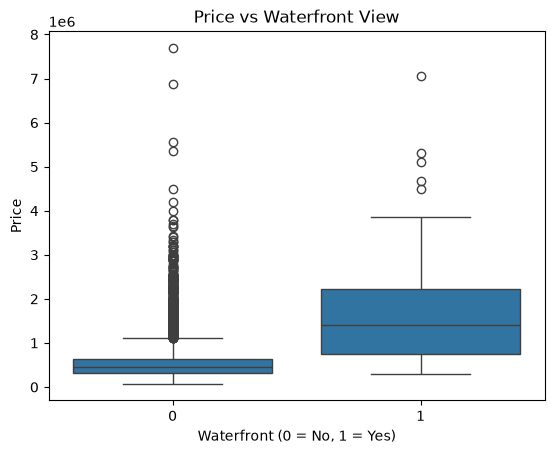

In [14]:


sns.boxplot(x="waterfront", y="price", data=df)
plt.title("Price vs Waterfront View")
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.show()


## Step 6: Regplot – Correlation between sqft_above and Price
Use a seaborn regression plot to visualize the linear relationship between above-ground square footage and price. The regression line shows the trend direction and strength of the correlation.

**Expected output:** A scatter plot with an upward-sloping red regression line, confirming a positive correlation — larger `sqft_above` values correspond to higher prices.

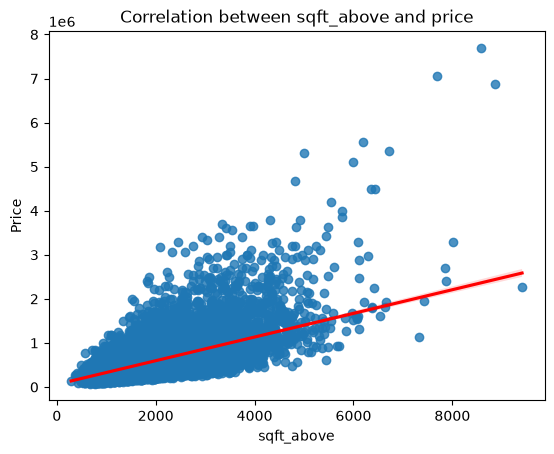

In [15]:
sns.regplot(x="sqft_above", y="price", data=df, line_kws={"color": "red"})
plt.title("Correlation between sqft_above and price")
plt.xlabel("sqft_above")
plt.ylabel("Price")
plt.show()


## Step 7: Simple Linear Regression – sqft_living vs Price
Fit a linear regression model using `sqft_living` as the sole feature to predict `price`. Calculate R² to measure how much variance in price is explained by living area alone.

**Expected output:** `R² = 0.4929` — living area alone explains ~49% of the price variance, a moderate but insufficient single-feature model.

In [16]:


X = df[["sqft_living"]]
y = df["price"]

lm = LinearRegression()
lm.fit(X, y)

r2 = lm.score(X, y)
print(f"R² = {r2:.4f}")


R² = 0.4929


## Step 8: Multiple Linear Regression – 11 Features vs Price
Extend the model by using 11 features (floors, waterfront, lat, bedrooms, etc.) to predict price. A higher R² compared to Step 7 confirms that multiple features explain more variance.

**Expected output:** `R² (multiple features) = 0.6577` — a significant improvement over the single-feature model, explaining ~66% of price variance.

In [17]:
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement",
            "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X_multi = df[features]
y = df["price"]

lm_multi = LinearRegression()
lm_multi.fit(X_multi, y)

r2_multi = lm_multi.score(X_multi, y)
print(f"R² (multiple features) = {r2_multi:.4f}")


R² (multiple features) = 0.6577


## Step 9: Pipeline – StandardScaler + PolynomialFeatures + LinearRegression
Build a scikit-learn Pipeline that chains feature scaling, polynomial feature generation (degree=2), and linear regression. This approach prevents data leakage and captures non-linear relationships between features and price.

**Expected output:** `R² (pipeline) = 0.7513` — polynomial feature expansion raises explained variance to ~75%, a notable gain over plain multiple regression.

In [18]:


features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement",
            "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X_pipe = df[features]
y = df["price"]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

pipe.fit(X_pipe, y)

r2_pipe = pipe.score(X_pipe, y)
print(f"R² (pipeline) = {r2_pipe:.4f}")


R² (pipeline) = 0.7513


## Step 10: Ridge Regression with Train/Test Split
Split the data into 80% training and 20% test sets, then fit a Ridge regression model (alpha=0.1). Evaluating R² on the test set gives a realistic measure of how well the model generalizes to unseen data.

**Expected output:** `R² (Ridge, alpha=0.1) = 0.6460` — evaluated on the test set, Ridge with regularization performs comparably to plain multiple regression.

In [19]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement",
            "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X_ridge = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X_ridge, y, test_size=0.2, random_state=1)

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

r2_ridge = ridge.score(X_test, y_test)
print(f"R² (Ridge, alpha=0.1) = {r2_ridge:.4f}")


R² (Ridge, alpha=0.1) = 0.6460


## Step 11: Polynomial Transform + Ridge Regression
Apply a degree-2 polynomial transform to the training and test features, then fit Ridge regression (alpha=0.1). Combining polynomial expansion with regularization captures non-linear patterns while preventing overfitting from the large number of generated features.

**Expected output:** `R² (Polynomial + Ridge, alpha=0.1) = 0.7546` — the best-performing model, combining expressiveness with regularization for optimal generalization.

In [20]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge_poly = Ridge(alpha=0.1)
ridge_poly.fit(X_train_poly, y_train)

r2_ridge_poly = ridge_poly.score(X_test_poly, y_test)
print(f"R² (Polynomial + Ridge, alpha=0.1) = {r2_ridge_poly:.4f}")


R² (Polynomial + Ridge, alpha=0.1) = 0.7546


## Conclusion

This analysis explored the King County house sales dataset using various regression techniques to predict house prices. Below is a summary of the R² scores achieved:

| Model | R² Score |
|---|---|
| Simple Linear Regression (`sqft_living`) | 0.4929 |
| Multiple Linear Regression (11 features) | 0.6577 |
| Pipeline (StandardScaler + Poly + LR) | 0.7513 |
| Ridge Regression (alpha=0.1) | 0.6460 |
| Polynomial + Ridge (alpha=0.1) | **0.7546** |

### Key Findings

1. **Single feature is insufficient** — Using only `sqft_living` yields R² = 0.49, meaning roughly half of the price variance is unexplained.

2. **Multiple features improve the model** — Adding 11 features (location, grade, view, etc.) raises R² to 0.66, confirming that house price is influenced by many factors beyond just size.

3. **Polynomial features boost accuracy** — The Pipeline with degree-2 polynomial expansion achieves R² = 0.75, capturing non-linear relationships between features and price.

4. **Waterfront is a strong price driver** — The boxplot clearly showed waterfront properties command significantly higher prices with more outliers at the top end.

5. **Best model: Polynomial + Ridge (R² = 0.7546)** — Combining polynomial feature expansion with Ridge regularization produces the highest generalization performance on the test set, balancing complexity and overfitting prevention.